# Identifying potential customers and the best platform for reaching them

#### Analysis of survey data focusing on respondents' habits related to checking the weather and using for this purpose a smartwatch.

Respondents answered 8 questions which also included their basic demographics.

Based on this data conclusions are drawn regarding expected efficiency of advertising a new smartwatch in specific channels.

#### Data source: https://github.com/fivethirtyeight/data/tree/master/weather-check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gos12/Data-Analytics-Portfolio
/blob/main/Python_Weather_reports.ipynb)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tcr
import numpy as np
%matplotlib inline

### Data exploration

In [4]:
#Survey overview
url='https://raw.githubusercontent.com/fivethirtyeight/data/master/weather-check/weather-check.csv'
weather=pd.read_csv(url, sep=',')
weather.head()

,RespondentID,Do you typically check a daily weather report?,How do you typically check the weather?,A specific website or app (please provide the answer),"If you had a smartwatch (like the soon to be released Apple Watch), how likely or unlikely would you be to check the weather on that device?",Age,What is your gender?,How much total combined money did all members of your HOUSEHOLD earn last year?,US Region
0,3887201482,Yes,The default weather app on your phone,-,Very likely,30 - 44,Male,"$50,000 to $74,999",South Atlantic
1,3887159451,Yes,The default weather app on your phone,-,Very likely,18 - 29,Male,Prefer not to answer,-
2,3887152228,Yes,The default weather app on your phone,-,Very likely,30 - 44,Male,"$100,000 to $124,999",Middle Atlantic
3,3887145426,Yes,The default weather app on your phone,-,Somewhat likely,30 - 44,Male,Prefer not to answer,-
4,3887021873,Yes,A specific website or app (please provide the ...,Iphone app,Very likely,30 - 44,Male,"$150,000 to $174,999",Middle Atlantic


In [5]:
#Dataset's size
weather.shape

(928, 9)

In [6]:
#Questions and data types
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 9 columns):
 #   Column                                                                                                                                        Non-Null Count  Dtype
---  ------                                                                                                                                        --------------  -----
 0   RespondentID                                                                                                                                  928 non-null    int64
 1   Do you typically check a daily weather report?                                                                                                928 non-null    str  
 2   How do you typically check the weather?                                                                                                       928 non-null    str  
 3   A specific website or app (please provide the answer)    

### Data cleaning

In [7]:
#assigning abbrevations of long column names for convenience
col_n={'check':'Do you typically check a daily weather report?',
       'source':'How do you typically check the weather?',
       'site':'A specific website or app (please provide the answer)',
       'likely':'If you had a smartwatch (like the soon to be released Apple Watch), how likely or unlikely would you be to check the weather on that device?', 
       'gender':'What is your gender?',
       'earn':'How much total combined money did all members of your HOUSEHOLD earn last year?',
       'region':'US Region'}

In [8]:
#replace '-' with 'No response given' for clearer charts
def repl():
    for c in weather[col_n.values()]:
        for i in weather.index:
            if weather.at[i,c]=='-':
                weather.at[i,c]='No response given'
repl()

## ANALYSIS

### QUESTION: Are people who typically check the daily weather report more likely to use a smartwatch for this purpose?

In [9]:
#listing possible answers to the question 'If you had a smartwatch, how likely or unlikely would you be to check the weather on that device?' 
weather[col_n['likely']].unique()  

<ArrowStringArray>
[      'Very likely',   'Somewhat likely',     'Very unlikely',
 'No response given', 'Somewhat unlikely']
Length: 5, dtype: str

In [10]:
#preparing data for presenting in a table
y_likely=weather[weather[col_n['check']]=='Yes']
y_likely=y_likely.groupby(col_n['likely']).size()
y_likely=y_likely.to_frame().reset_index()
y_likely.columns=['Check weather via smartwatch?','DO check the weather']
n_likely=weather[weather[col_n['check']]=='No']
n_likely=n_likely.groupby(col_n['likely']).size()
n_likely=n_likely.to_frame().reset_index()
n_likely.columns=['Check weather via smartwatch?','DO NOT check the weather']
likely_df=y_likely.merge(n_likely,how='outer')
likely_df.set_index('Check weather via smartwatch?',inplace=True)
likely_df=likely_df.reindex(['Very likely', 'Somewhat likely', 'Somewhat unlikely', 'Very unlikely', 'No response given'])
likely_df=likely_df.fillna(0).astype(int)
likely_df

,DO check the weather,DO NOT check the weather
Check weather via smartwatch?,,
Very likely,334,28
Somewhat likely,203,71
Somewhat unlikely,48,25
Very unlikely,155,53
No response given,6,5


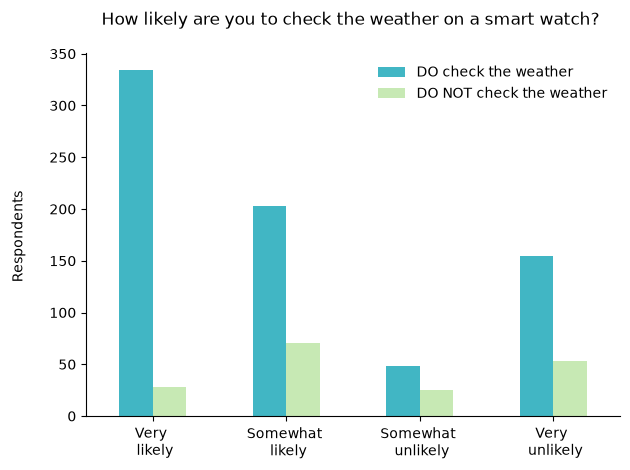

In [11]:
#creating a bar chart for a visual comparison of respondents regularly checking versus not checking the weather forecast
#removing 'No response given' row as it does not contribute to the understanding of the data
likely_df_p=likely_df.drop(['No response given'])
color=['#41b6c4', '#c7e9b4']
ax = likely_df_p.plot.bar(rot=0, color=color)
plt.title('How likely are you to check the weather on a smart watch? \n')
plt.xlabel('')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Very \n likely', 'Somewhat \n likely', 'Somewhat \n unlikely', 'Very \n unlikely'])
plt.ylabel("Respondents \n")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.legend().get_frame().set_linewidth(0.0)  #removing legend border
plt.tight_layout()

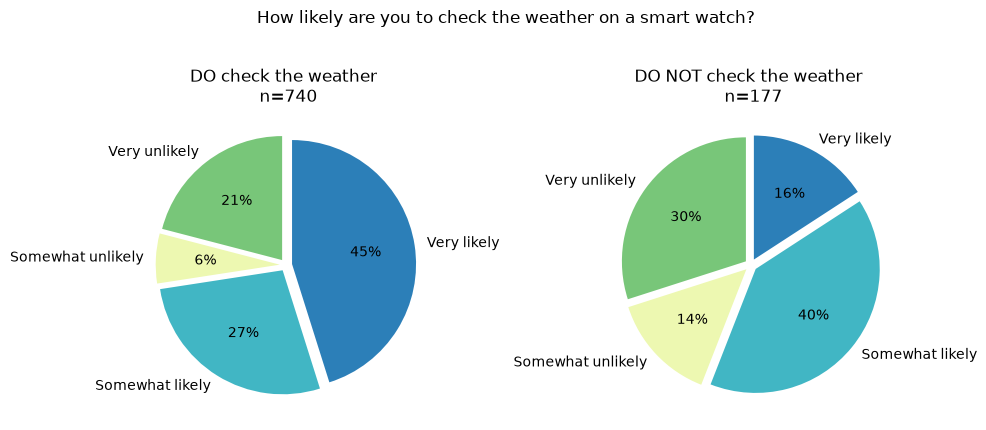

In [12]:
#since the total number of respondents checking the forecast significantly exceeds the 'not checking' group it is better to represent the data 
#as percentages using a pie chart - this allows for a better understanding of proportions in both groups
t1='DO check the weather \n n='+str(round(likely_df_p['DO check the weather'].sum()))
t2='DO NOT check the weather \n n='+str(round(likely_df_p['DO NOT check the weather'].sum()))
color=[ '#2c7fb8', '#41b6c4', '#edf8b1', '#78c679']

axes=likely_df_p.plot(kind='pie', subplots=True, autopct='%.f%%', 
                    explode=(0.05, 0.05, 0.05, 0.05), counterclock =False, 
                    startangle=90, figsize=(10,10), legend=False,
                    title=[t1,t2], colors=color)
for ax in axes:
    ax.set_ylabel('')
    
plt.subplots_adjust(wspace=0.5)
plt.suptitle('How likely are you to check the weather on a smart watch?', fontsize=12, y=0.75)
plt.show()

#### CONCLUSION: 
Persons who typically check a daily weather report do claim they would be more likely to use for this purpose a smartwatch if they had one:
*    "Very likely": 45% vs. 15%
*    "Very" and "Somewhat likely" combined: 72% vs. 54%

This is an intuitive conclusion showing that persons who are in general interested in getting weather information would also be more interested in receiving this information using a smartwatch.

Of course, based on this question alone we do not know how many of these persons would be willing to buy a smartwatch.
However, it is a useful indication for an advertisement campaign focusing on this particular smartwatch functionality. It suggests that directing the message to persons already interested in checking the forecast might bring better results than trying to convince the uninterested ones.

For the purpose of advertising it will also be useful to identify what weather information sources are especially popular among the respondents.

### Based on the above conclusion in the further analysis we will look ONLY at the persons who do TYPICALLY CHECK the weather report 

### QUESTION: Do persons likely to use a smartwatch to check the weather use predominantly any specific weather info source?

and... 
Do they differ from those who describe themselves as unlikely to use it?

In [13]:
#creating dataframe for presenting the data on weather forecast sources
source_df=pd.DataFrame(weather[[col_n['likely'], col_n['source'], col_n['site']]][weather[col_n['check']]=='Yes'])
source_df_l=source_df[source_df[col_n['likely']].isin(['Very likely', 'Somewhat likely'])]
source_df_l_s=source_df_l.groupby(col_n['source']).size().sort_values(ascending=False)
source_df_l_s=source_df_l_s.to_frame().reset_index()
source_df_l_s.columns=['Source', 'Likely']
source_df_l_s['Likely %']=source_df_l_s.Likely/source_df_l_s.Likely.sum()
source_df_l_s['Likely %']=source_df_l_s['Likely %'].astype(float).map('{:.0%}'.format)

source_df_u=source_df[source_df[col_n['likely']].isin(['Very unlikely', 'Somewhat unlikely'])]
source_df_u_s=source_df_u.groupby(col_n['source']).size().to_frame().reset_index()
source_df_u_s.columns=['Source', 'Unlikely']
source_df_u_s['Unlikely %']=source_df_u_s.Unlikely/source_df_u_s.Unlikely.sum()
source_df_u_s['Unlikely %']=source_df_u_s['Unlikely %'].astype(float).map('{:.0%}'.format)

source_df=source_df_l_s.merge(source_df_u_s,how='outer')
source_df['Source'] = source_df['Source'].replace('A specific website or app (please provide the answer)', 'A specific website or app')
source_df.set_index('Source', inplace=True)

#### Sources of weather information for respondents likely and unlikely to use a smartwatch

In [14]:
source_df

,Likely,Likely %,Unlikely,Unlikely %
Source,,,,
A specific website or app,122,23%,35,17%
Internet search,64,12%,26,13%
Local TV News,96,18%,52,26%
Newsletter,3,1%,3,1%
Newspaper,15,3%,9,4%
Radio weather,13,2%,10,5%
The Weather Channel,87,16%,35,17%
The default weather app on your phone,137,26%,33,16%


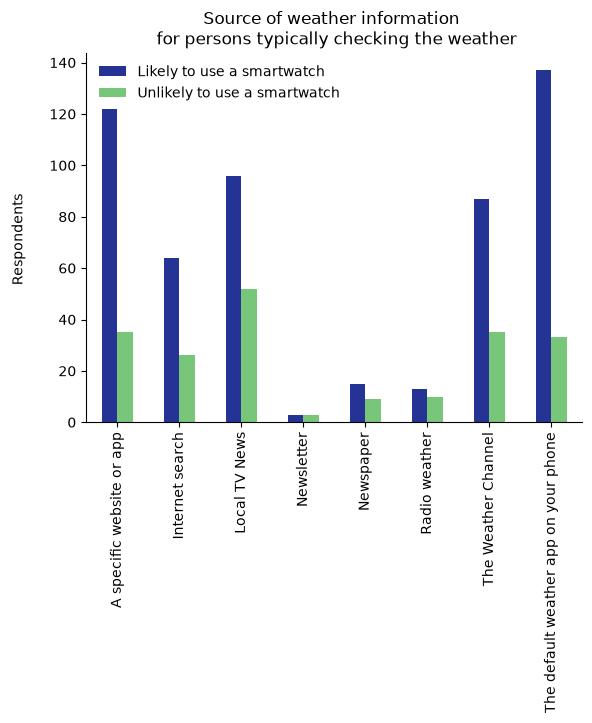

In [15]:
#bar chart - persons likely vs. unlikely to check the weather on a smartwatch - 
# - what source on weather information do they currently use?

color=['#253494', '#78c679']
#renaming column names for a more readable legend
source_df_p=source_df
source_df_p.columns=['Likely to use a smartwatch', 'Likely %', 'Unlikely to use a smartwatch', 'Unlikely %'] 
#plotting
ax = source_df_p.plot.bar(y=['Likely to use a smartwatch', 'Unlikely to use a smartwatch'], color=color)
#title, labels, formatting
plt.title('Source of weather information \n for persons typically checking the weather')
plt.ylabel("Respondents \n")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.xlabel('')
plt.legend().get_frame().set_linewidth(0.0) #removing legend border

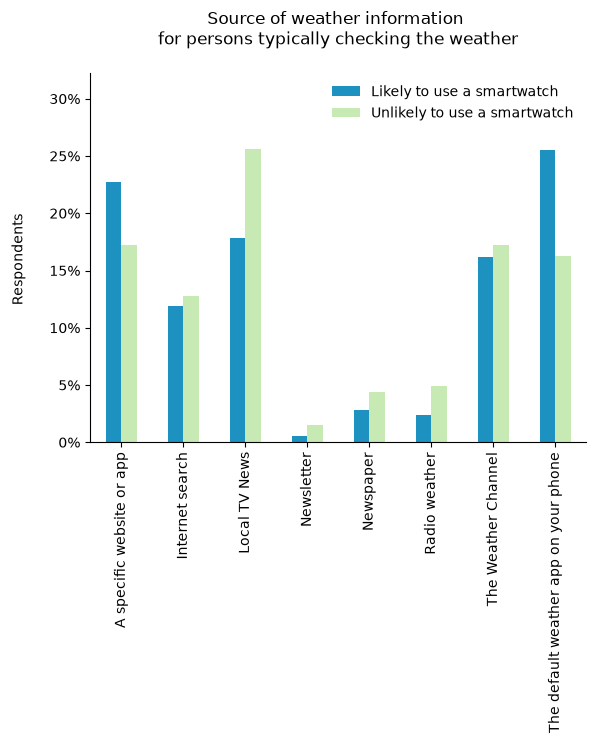

In [16]:
#the same as above with % values
#comparing percentages respectively of persons likely/unlikely to use a smartwatch for checking the weather

#creating dataframe
source_df_l_s['Likely to use a smartwatch']=source_df_l_s.Likely/source_df_l_s.Likely.sum()
source_df_u_s['Unlikely to use a smartwatch']=source_df_u_s.Unlikely/source_df_u_s.Unlikely.sum()

source_df_f=source_df_l_s.merge(source_df_u_s,how='outer')
source_df_f['Source']=source_df_f['Source'].replace('A specific website or app (please provide the answer)', \
                                'A specific website or app')
source_df_f.set_index('Source', inplace=True)

#bar chart
color=['#1d91c0', '#c7e9b4']
ax=source_df_f.plot.bar(y=['Likely to use a smartwatch', 'Unlikely to use a smartwatch'], color=color)
ax.yaxis.set_major_formatter(tcr.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))  
plt.ylim(top=ax.get_ylim()[1] * 1.20) #prolonging the y axis to fit the legend above the bars
plt.title('Source of weather information \n for persons typically checking the weather \n')
plt.ylabel("Respondents \n")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.xlabel('')
plt.legend().get_frame().set_linewidth(0.0) #removing legend border

### CONCLUSION: 
Persons more likely to use a smartwatch for checking the weather also use weather apps or websites more frequently.

Persons less likely to use a smartwatch for forecast tend to get their weather information rather from the tv (top result), newspaper or radio.

The conclusion is intuitive: persons who already use their smartphones for weather forecast are more willing to use another smart device.

### Let's check what kind of "a specific website or app" do these persons use, as it might provide valuable insight into the specific channels for reaching these potential customers with advertisement.

### QUESTION: What websites or apps do our potential customers use? 

Potential customers defined as: 

   * typically checking the weather forecast
   * likely to use a smartwatch to check the forecast

In [17]:
#creating a list of websites and apps used by the potential customers (dataframe)
site_df=weather[[col_n['likely'], col_n['source'], col_n['site']]][weather[col_n['check']]=='Yes']
site_df=site_df[site_df[col_n['likely']].isin(['Very likely', 'Somewhat likely'])]
site_df=site_df[site_df[col_n['source']]=='A specific website or app (please provide the answer)']
site_df['A specific website or app (please provide the answer)'].unique()

<ArrowStringArray>
[                                            'Iphone app',
                                        'AccuWeather App',
                                                   'nice',
                                             'Weatherbug',
                                    'weather channel app',
                                   'Yahoo weather iphone',
                                          'Weather Puppy',
                                            'AccuWeather',
                                           'Apple weater',
                                'The Weather Channel app',
                                       'google "weather"',
                                    'Weather Underground',
                                              '1 weather',
                                    'Weather Channel app',
 'Weather Underground, also local tv news half the time.',
                                         'weatherbug app',
         'FancyClock app on my phone 

#### There are 88 different websites or apps provided.
Many of them are repeating but with varying spelling. 
This number needs to be reduced for a meaningful analysis.

After a quick glance a few typical answers stand out: 'weather channel', 'accuweather', 'weatherbug', 'weather underground', 'weather.com' and answers indicating the use of the default app.

Creating uniform names for these ones first and checking what we is left.

In [18]:
#creating a new list with uniform names
site_df['site_cat']=""

def source_f():
    for i in site_df.index:
        if site_df.at[i,col_n['site']].lower().find('weather channel')>=0: 
            site_df.at[i,'site_cat']='weather channel'
        elif site_df.at[i,col_n['site']].lower().find('accuweather')>=0: 
            site_df.at[i,'site_cat']='accuweather'
        elif site_df.at[i,col_n['site']].lower().find('weatherbug')>=0: 
            site_df.at[i,'site_cat']='weatherbug'
        elif site_df.at[i,col_n['site']].lower().find('weather bug')>=0: 
            site_df.at[i,'site_cat']='weatherbug'
        elif site_df.at[i,col_n['site']].lower().find('weather underground')>=0: 
            site_df.at[i,'site_cat']='weather underground'
        elif site_df.at[i,col_n['site']].lower().find('weatherunderground')>=0: 
            site_df.at[i,'site_cat']='weather underground'
        elif site_df.at[i,col_n['site']].lower().find('weather.com')>=0: 
            site_df.at[i,'site_cat']='weather.com'
        elif site_df.at[i,col_n['site']].lower().find('iphone')>=0: 
            site_df.at[i,'site_cat']='default app'
        elif site_df.at[i,col_n['site']].lower().find('ipad')>=0: 
            site_df.at[i,'site_cat']='default app'       
        elif site_df.at[i,col_n['site']].lower().find('apple')>=0: 
            site_df.at[i,'site_cat']='default app'
        elif site_df.at[i,col_n['site']].lower().find('weather app')>=0: 
            site_df.at[i,'site_cat']='default app'
        else:
            site_df.at[i,'site_cat']=site_df.at[i,col_n['site']]       
            
source_f()
site_df.site_cat.unique()

<ArrowStringArray>
[                             'default app',
                              'accuweather',
                                     'nice',
                               'weatherbug',
                          'weather channel',
                            'Weather Puppy',
                         'google "weather"',
                      'weather underground',
                                '1 weather',
                      'Intellicast / Storm',
                            'ipod weather ',
                     'www.wunderground.com',
                                 'noaa.gov',
                                 '1weather',
                                    'yahoo',
                                 'Dark Sky',
                            'Weather Kitty',
           'Internet, tv, radio, newspaper',
                                    'yr.no',
                              'weather.com',
                             'Weather Risk',
                             'Storm 

#### Let's check if any of the remaining answers appear multiple times

In [19]:
site_gr=site_df.groupby('site_cat').size().sort_values(ascending=False)
site_gr

site_cat
weather channel                             23
accuweather                                 18
weatherbug                                  17
default app                                 17
weather.com                                 10
weather underground                          9
intellicast                                  2
1 weather                                    1
1weather                                     1
Internet, tv, radio, newspaper               1
Bing                                         1
Chrome app                                   1
Dark Sky                                     1
Google App                                   1
Google now                                   1
Intellicast (site) & WUnderground (app)      1
Intellicast / Storm                          1
Wunderground                                 1
Weather Risk                                 1
Weather Puppy                                1
Weather Kitty                                1
Weat

#### 'Intellicast' stands out a more frequent answer, so a new category will be created for it.

#### Remaining answers will be added to a common category of 'other'.

In [20]:
#creating a function to assign uniform names to all the answers
def source_f():
    for i in site_df.index:
        if site_df.at[i,col_n['site']].lower().find('weather channel')>=0: 
            site_df.at[i,'site_cat']='weather channel'
        elif site_df.at[i,col_n['site']].lower().find('accuweather')>=0: 
            site_df.at[i,'site_cat']='accuweather'
        elif site_df.at[i,col_n['site']].lower().find('weatherbug')>=0: 
            site_df.at[i,'site_cat']='weatherbug'
        elif site_df.at[i,col_n['site']].lower().find('weather bug')>=0: 
            site_df.at[i,'site_cat']='weatherbug'
        elif site_df.at[i,col_n['site']].lower().find('weather underground')>=0: 
            site_df.at[i,'site_cat']='weather underground'
        elif site_df.at[i,col_n['site']].lower().find('weatherunderground')>=0: 
            site_df.at[i,'site_cat']='weather underground'
        elif site_df.at[i,col_n['site']].lower().find('weather.com')>=0: 
            site_df.at[i,'site_cat']='weather.com'
        elif site_df.at[i,col_n['site']].lower().find('intellicast')>=0: 
            site_df.at[i,'site_cat']='intellicast'
        elif site_df.at[i,col_n['site']].lower().find('iphone')>=0: 
            site_df.at[i,'site_cat']='default app'
        elif site_df.at[i,col_n['site']].lower().find('ipad')>=0: 
            site_df.at[i,'site_cat']='default app'       
        elif site_df.at[i,col_n['site']].lower().find('apple')>=0: 
            site_df.at[i,'site_cat']='default app'
        elif site_df.at[i,col_n['site']].lower().find('weather app')>=0: 
            site_df.at[i,'site_cat']='default app'
        else:
            site_df.at[i,'site_cat']='other'       
            
source_f()
site_df.groupby('site_cat').size().sort_values(ascending=False)

site_cat
other                  24
weather channel        23
accuweather            18
default app            17
weatherbug             17
weather.com            10
weather underground     9
intellicast             4
dtype: int64

### CONCLUSION:

The top websites/apps that our potential customers use are:
   * weather channel
   * accuweather
   * weatherbug

They might be good choices for an advertisement campaign of the new Apple smartwatch.